In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [3]:
df = pd.read_csv(r"/content/drive/MyDrive/Final Year Project/master_features_nca.csv")
df

,filename,cell_id,temp,charge_rate,discharge_rate,cycle,SOH,IC_bin_1,IC_bin_2,IC_bin_3,...,IC_bin_11,IC_bin_12,IC_bin_13,IC_bin_14,IC_bin_15,IC_bin_16,IC_bin_17,IC_bin_18,IC_bin_19,IC_bin_20
0,CY25-025_1-#1.csv,1,25,0.25,1.0,1,99.96,3.206253,3.435524,3.772510,...,4.255246,4.207070,4.229390,4.248806,4.264151,4.198406,4.058616,3.920543,3.792856,3.647914
1,CY25-025_1-#1.csv,1,25,0.25,1.0,2,99.98,3.185611,3.409977,3.737496,...,4.249921,4.223132,4.181276,4.225006,4.231327,4.158785,4.055173,3.905594,3.737473,3.648392
2,CY25-025_1-#1.csv,1,25,0.25,1.0,3,100.00,3.166235,3.397673,3.713245,...,4.235653,4.189766,4.140167,4.167926,4.180849,4.145106,4.015124,3.896722,3.756668,3.646670
3,CY25-025_1-#1.csv,1,25,0.25,1.0,4,99.97,3.139468,3.376350,3.683448,...,4.254307,4.162355,4.134256,4.143371,4.135573,4.118733,4.023064,3.867330,3.752034,3.631178
4,CY25-025_1-#1.csv,1,25,0.25,1.0,5,99.93,3.132129,3.346752,3.653736,...,4.216513,4.164974,4.094929,4.101335,4.135343,4.100581,4.008745,3.881142,3.761407,3.626212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22639,CY45-05_1-#9.csv,9,45,0.50,1.0,411,84.65,2.514883,2.565545,2.627766,...,3.248165,3.376864,3.545380,3.705835,3.774339,3.705556,3.564230,3.413748,3.287599,3.193869
22640,CY45-05_1-#9.csv,9,45,0.50,1.0,412,84.61,2.510205,2.560754,2.625429,...,3.250500,3.392370,3.559592,3.706725,3.763518,3.694866,3.559024,3.417873,3.299083,3.207045
22641,CY45-05_1-#9.csv,9,45,0.50,1.0,413,84.60,2.513525,2.562124,2.623266,...,3.245492,3.372555,3.540142,3.694258,3.752898,3.692722,3.562536,3.425323,3.303745,3.206924
22642,CY45-05_1-#9.csv,9,45,0.50,1.0,414,84.58,2.508238,2.557557,2.619624,...,3.241048,3.372799,3.540815,3.700767,3.761809,3.701606,3.569719,3.425509,3.299934,3.202914


In [4]:
import sys
sys.path.append('/content/drive/MyDrive/Final Year Project')

from data_preprocessor import DataPreprocessor

preprocessor = DataPreprocessor(
    train_size=0.8,
    ic_low=0,
    ic_high=20
)

data = preprocessor.preprocess(df)

X_ic_train = data["X_ic_train"]
X_context_train = data["X_context_train"]
y_train_norm = data["y_train"]


print("Train Data shape:")
print("X_ic_train shape:", X_ic_train.shape)
print("X_context_train shape:", X_context_train.shape)
print("y_train shape:",y_train_norm.shape)



Train Data shape:
X_ic_train shape: (18109, 20, 1)
X_context_train shape: (18109, 7)
y_train shape: (18109,)


In [5]:
X_ic_test = data['X_ic_test']
X_context_test = data['X_context_test']
y_test_norm = data['y_test']

y_mean = data['y_mean']
y_std = data['y_std']

print("Test data shape:")
print("X_ic_test shape:", X_ic_test.shape)
print("X_context_test shape:", X_context_test.shape)
print("Y_test shape:", y_test_norm.shape)

Test data shape:
X_ic_test shape: (4528, 20, 1)
X_context_test shape: (4528, 7)
Y_test shape: (4528,)


In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# Check GPU availability
print("="*60)
print("GPU CHECK")
print("="*60)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {gpus}")

    # Set memory growth to avoid OOM
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"   Memory growth set for {gpu.name}")
        except RuntimeError as e:
            print(f"   ❌ Could not set memory growth for {gpu.name}: {e}")
            print("      This usually means the GPU devices have already been initialized.")

    # Verify tensor placement
    with tf.device('/GPU:0'):
        test_tensor = tf.random.normal((100, 100))
        result = tf.matmul(test_tensor, test_tensor)
    print(f"✅ GPU test successful: {result.device}")
else:
    print("❌ No GPU found - training will be slow!")

print("="*60)

GPU CHECK
✅ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Memory growth set for /physical_device:GPU:0
✅ GPU test successful: /job:localhost/replica:0/task:0/device:GPU:0


In [8]:
from tqdm import tqdm

batch_size = 32

y_train_tf = y_train_norm.reshape(-1,1).astype(np.float32)
y_test_tf = y_test_norm.reshape(-1,1).astype(np.float32)

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_ic_train.astype(np.float32),X_context_train.astype(np.float32),
     y_train_tf)).shuffle(buffer_size=len(X_ic_train)).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_ic_test.astype(np.float32), X_context_test.astype(np.float32),
    y_test_tf)).batch(batch_size)

In [9]:
def candw_attack_batch(model, x_ic, x_ctx, y_true, c=100.0, lr=0.02, steps=300, clip_min=-3.0, clip_max=3.0):
    """
    CW attack that maximizes error relative to true SOH
    """
    x_ic = tf.cast(x_ic, tf.float32)
    x_ctx = tf.cast(x_ctx, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    # Ensure y_true has correct shape
    if tf.rank(y_true) == 1:
        y_true = tf.expand_dims(y_true, axis=-1)

    c = tf.cast(c, tf.float32)
    clip_min = tf.cast(clip_min, tf.float32)
    clip_max = tf.cast(clip_max, tf.float32)

    # Get original predictions for reference only
    y_clean = tf.stop_gradient(model([x_ic, x_ctx], training=False))

    z = tf.Variable(tf.zeros_like(x_ic), trainable=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=float(lr))

    half_range = (clip_max - clip_min) / 2.0
    mid = (clip_max + clip_min) / 2.0

    axes = tf.range(1, tf.rank(x_ic))

    for _ in range(int(steps)):
        with tf.GradientTape() as tape:
            x_adv = tf.tanh(z) * half_range + mid
            y_adv = model([x_adv, x_ctx], training=False)

            # Maximize MSE relative to TRUE y
            mse = tf.reduce_mean(tf.square(y_true - y_adv))

            # L2 distortion
            l2 = tf.reduce_mean(tf.reduce_sum(tf.square(x_adv - x_ic), axis=axes))

            # Loss: minimize distortion, maximize MSE
            loss = l2 - c * mse

        grads = tape.gradient(loss, z)
        if grads is not None:
            grads = tf.where(tf.math.is_finite(grads), grads, tf.zeros_like(grads))
            grads = tf.clip_by_value(grads, -1.0, 1.0)  # Stability
            optimizer.apply_gradients([(grads, z)])

    return tf.tanh(z) * half_range + mid


In [10]:
def plot_heatmap(
    matrix,
    title,
    y_labels,      # rows (deltas or c values)
    x_labels,      # cols (pairs or steps)
    cmap="plasma",
    annotate=True,
    as_percent=False,
):
    """
    Generic heatmap for adversarial evaluation.
    """

    # --- convert to percentage if needed ---
    display_matrix = matrix * 100 if as_percent else matrix

    plt.figure(figsize=(7, 5))

    im = plt.imshow(display_matrix, aspect="auto", cmap=cmap)

    # --- colorbar ---
    cbar = plt.colorbar(im)
    cbar.ax.tick_params(labelsize=10)

    if as_percent:
        cbar.set_label("Percentage (%)", fontsize=11)

    # --- ticks ---
    plt.xticks(range(len(x_labels)), x_labels, fontsize=11)
    plt.yticks(range(len(y_labels)), y_labels, fontsize=11)

    plt.xlabel("Steps / Max Pairs", fontsize=12)
    plt.ylabel("Delta / c", fontsize=12)
    plt.title(title, fontsize=13)

    # --- annotations ---
    if annotate:
        mean_val = np.mean(display_matrix)

        for i in range(display_matrix.shape[0]):
            for j in range(display_matrix.shape[1]):

                val = display_matrix[i, j]

                text = f"{val:.1f}%" if as_percent else f"{val:.3f}"

                plt.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    color="white" if val < mean_val else "black",
                    fontsize=8,
                )

    plt.tight_layout()
    plt.show()


In [11]:
from tabulate import tabulate

def cw_attack_evaluation(
    model,
    model_name,
    x_ic,
    x_ctx,
    y_true_norm,
    eps_list,        # sweep over c
    steps_list,      # sweep over optimization steps
    clip_min,
    clip_max,
    y_std,
    y_mean,
):
    # ===== tensor safety =====
    x_ic = tf.convert_to_tensor(x_ic, dtype=tf.float32)
    x_ctx = tf.convert_to_tensor(x_ctx, dtype=tf.float32)

    # ===== clean prediction =====
    y_clean_norm = model([x_ic, x_ctx], training=False).numpy().flatten()
    y_true = y_true_norm * y_std + y_mean
    y_clean = y_clean_norm * y_std + y_mean

    mae_clean = mean_absolute_error(y_true, y_clean)
    mse_clean = mean_squared_error(y_true, y_clean)

    # ===== plot clean =====
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_clean, s=8, alpha=0.7)
    min_v, max_v = y_true.min(), y_true.max()
    plt.plot([min_v, max_v], [min_v, max_v], "r--")
    plt.title(f"{model_name} — Clean\nMAE: {mae_clean:.4f}")
    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.grid(True)
    plt.show()

    # ===== storage =====
    MAE_map = np.zeros((len(eps_list), len(steps_list)))
    MAPE_map = np.zeros_like(MAE_map)
    table_rows = []

    # ===== subplot grid =====
    n_rows = len(eps_list)
    n_cols = len(steps_list)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), constrained_layout=True)

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    # ===== sweep =====
    for i, c_val in enumerate(eps_list):
        for j, step_val in enumerate(steps_list):

            # --- CW attack ---
            x_adv = candw_attack_batch(
                model,
                x_ic,
                x_ctx,
                y_true_norm,
                c=c_val,
                steps=step_val,
                clip_min=clip_min,
                clip_max=clip_max,
            )

            # --- prediction ---
            y_adv_norm = model([x_adv, x_ctx], training=False).numpy().flatten()
            y_adv = y_adv_norm * y_std + y_mean

            # --- metrics ---
            mae = mean_absolute_error(y_true, y_adv)
            mse = mean_squared_error(y_true, y_adv)
            mape = mean_absolute_percentage_error(y_true, y_adv)

            delta_mae = mae - mae_clean
            delta_mse = mse - mse_clean
            robustness = 1 - (delta_mae / (mae_clean + 1e-8))

            # --- store ---
            MAE_map[i, j] = mae
            MAPE_map[i, j] = mape

            table_rows.append([
                c_val,
                step_val,
                mse,
                mae,
                delta_mse,
                delta_mae,
                robustness
            ])

            # --- subplot ---
            ax = axes[i, j]
            ax.scatter(y_true, y_adv, s=8, color="orange", alpha=0.6)
            ax.plot([min_v, max_v], [min_v, max_v], "r--")
            ax.set_title(f"c={c_val}, steps={step_val}\nMAE={mae:.4f}")

            if i == n_rows - 1:
                ax.set_xlabel("True SOH")
            if j == 0:
                ax.set_ylabel("Adv SOH")

            ax.grid(True)

    plt.suptitle(f"{model_name} — CW Adversarial Sweep", fontsize=16)
    plt.show()

    # ===== table =====
    headers = ["c", "Steps", "MSE", "MAE", "ΔMSE", "ΔMAE", "Robustness"]

    print(f"\n=== CW Attack Results : {model_name} ===")
    print(tabulate(table_rows, headers=headers, floatfmt=".5f"))

    # ===== heatmaps =====
    plot_heatmap(MAE_map, f"{model_name} — CW MAE Heatmap", eps_list, steps_list, cmap="plasma")
    plot_heatmap(MAPE_map, f"{model_name} — CW MAPE Heatmap", eps_list, steps_list, cmap="plasma")
    plot_heatmap(MAPE_map, f"{model_name} — CW MAPE Heatmap", eps_list, steps_list, cmap="plasma", as_percent=True)

    return MAE_map, MAPE_map, table_rows


In [12]:
clip_min = np.percentile(X_ic_train, 0.5)
clip_max = np.percentile(X_ic_train, 99.5)

eps_list = [1, 5, 10, 50, 100]      # CW trade-off constant c
steps_list = [50, 100, 200, 400]    # optimization iterations


In [13]:
X_ic_test_tf  = tf.convert_to_tensor(X_ic_test, dtype=tf.float32)
X_ctx_test_tf = tf.convert_to_tensor(X_context_test, dtype=tf.float32)
y_test_norm_tf = tf.convert_to_tensor(y_test_tf, dtype=tf.float32)


--------
CNN+LSTM
--------


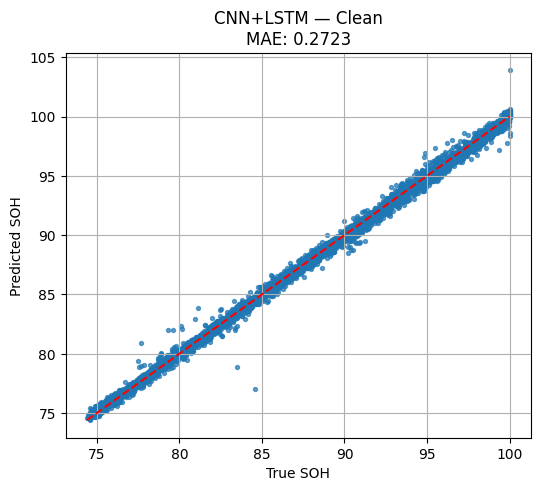

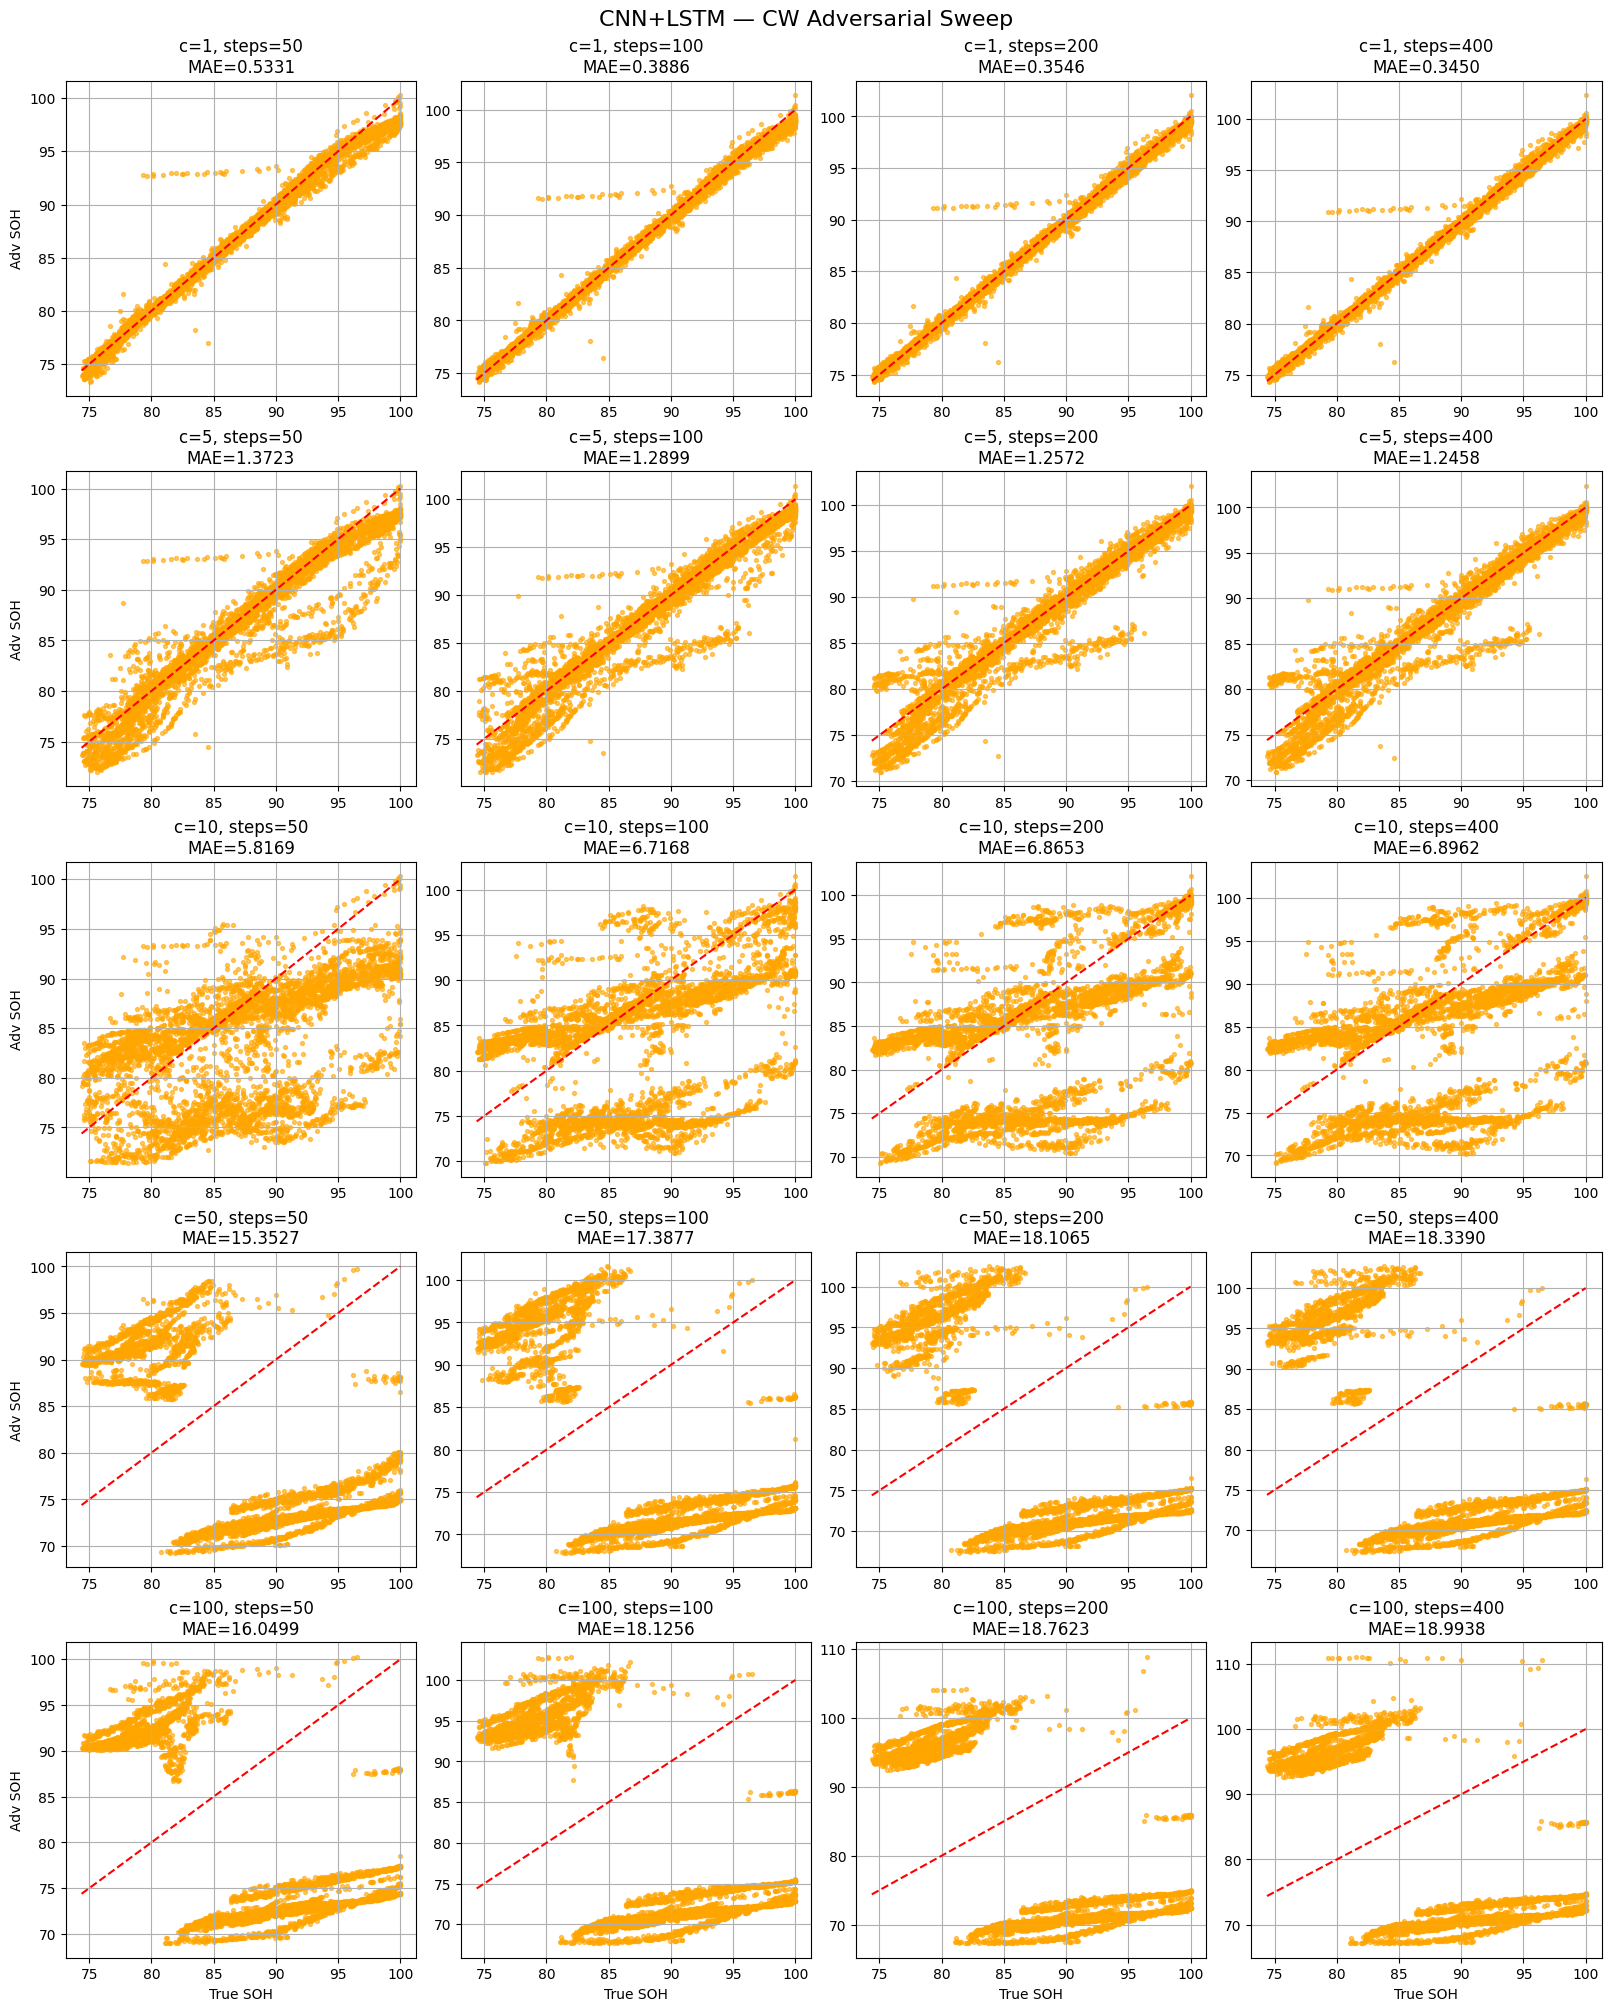


=== CW Attack Results : CNN+LSTM ===
  c    Steps        MSE       MAE       ΔMSE      ΔMAE    Robustness
---  -------  ---------  --------  ---------  --------  ------------
  1       50    0.99758   0.53307    0.84243   0.26073       0.04267
  1      100    0.58945   0.38855    0.43430   0.11621       0.57331
  1      200    0.50875   0.35463    0.35359   0.08228       0.69789
  1      400    0.48567   0.34501    0.33051   0.07266       0.73321
  5       50    5.16852   1.37228    5.01336   1.09993      -3.03872
  5      100    4.51073   1.28988    4.35558   1.01753      -2.73617
  5      200    4.45664   1.25717    4.30149   0.98482      -2.61606
  5      400    4.44346   1.24575    4.28830   0.97341      -2.57414
 10       50   52.93127   5.81686   52.77612   5.54452     -19.35826
 10      100   71.35667   6.71679   71.20152   6.44444     -22.66260
 10      200   75.07163   6.86530   74.91647   6.59295     -23.20788
 10      400   75.96933   6.89617   75.81418   6.62383     -23.32

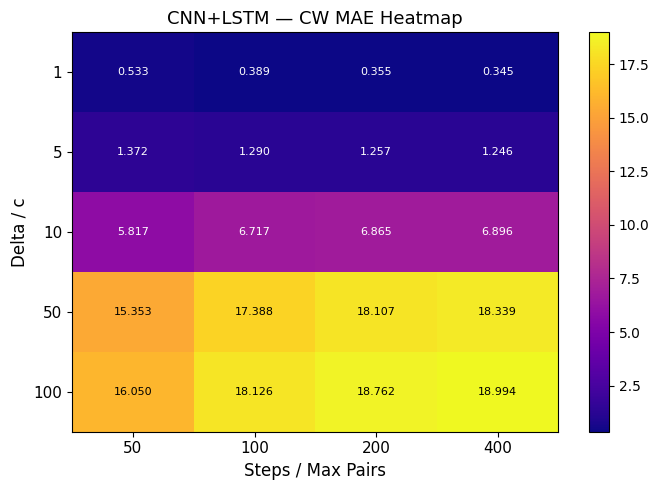

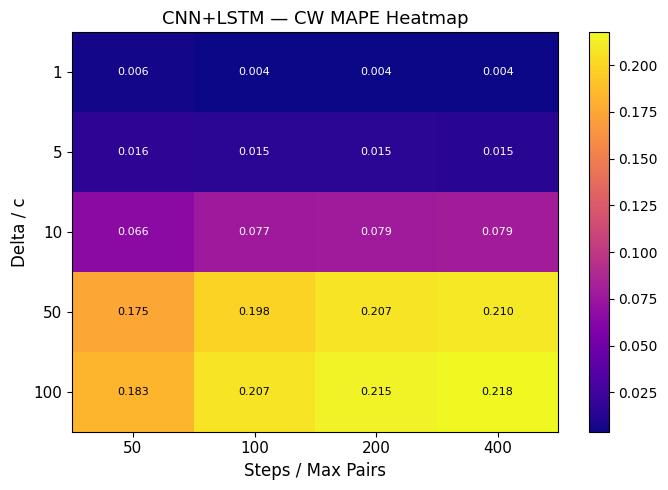

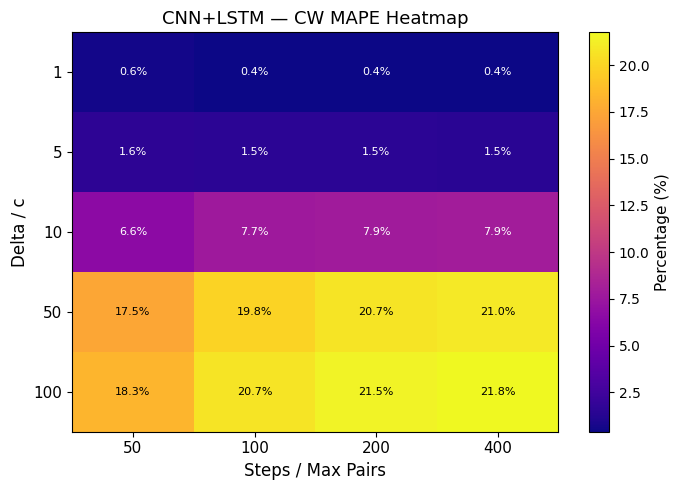

In [ ]:
print("--------")
print("CNN+LSTM")
print("--------")

cnn_lstm = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/attacks/CNN_LSTM_NT.keras")

MAE_cnn_lstm, MAPE_cnn_lstm, table_cnn_lstm = cw_attack_evaluation(
    model=cnn_lstm,
    model_name="CNN+LSTM",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    eps_list=eps_list,
    steps_list=steps_list,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)


--------
CNN+GRU
--------


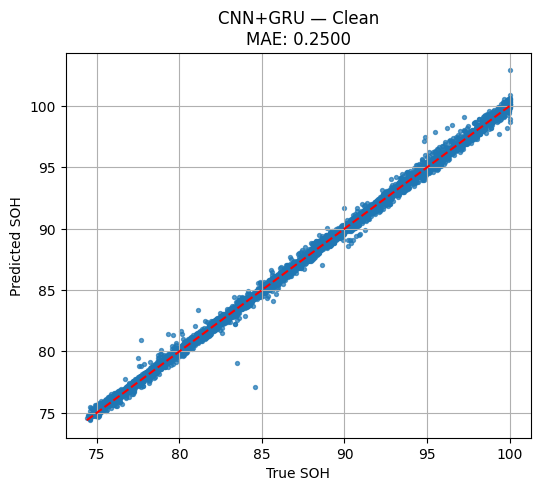

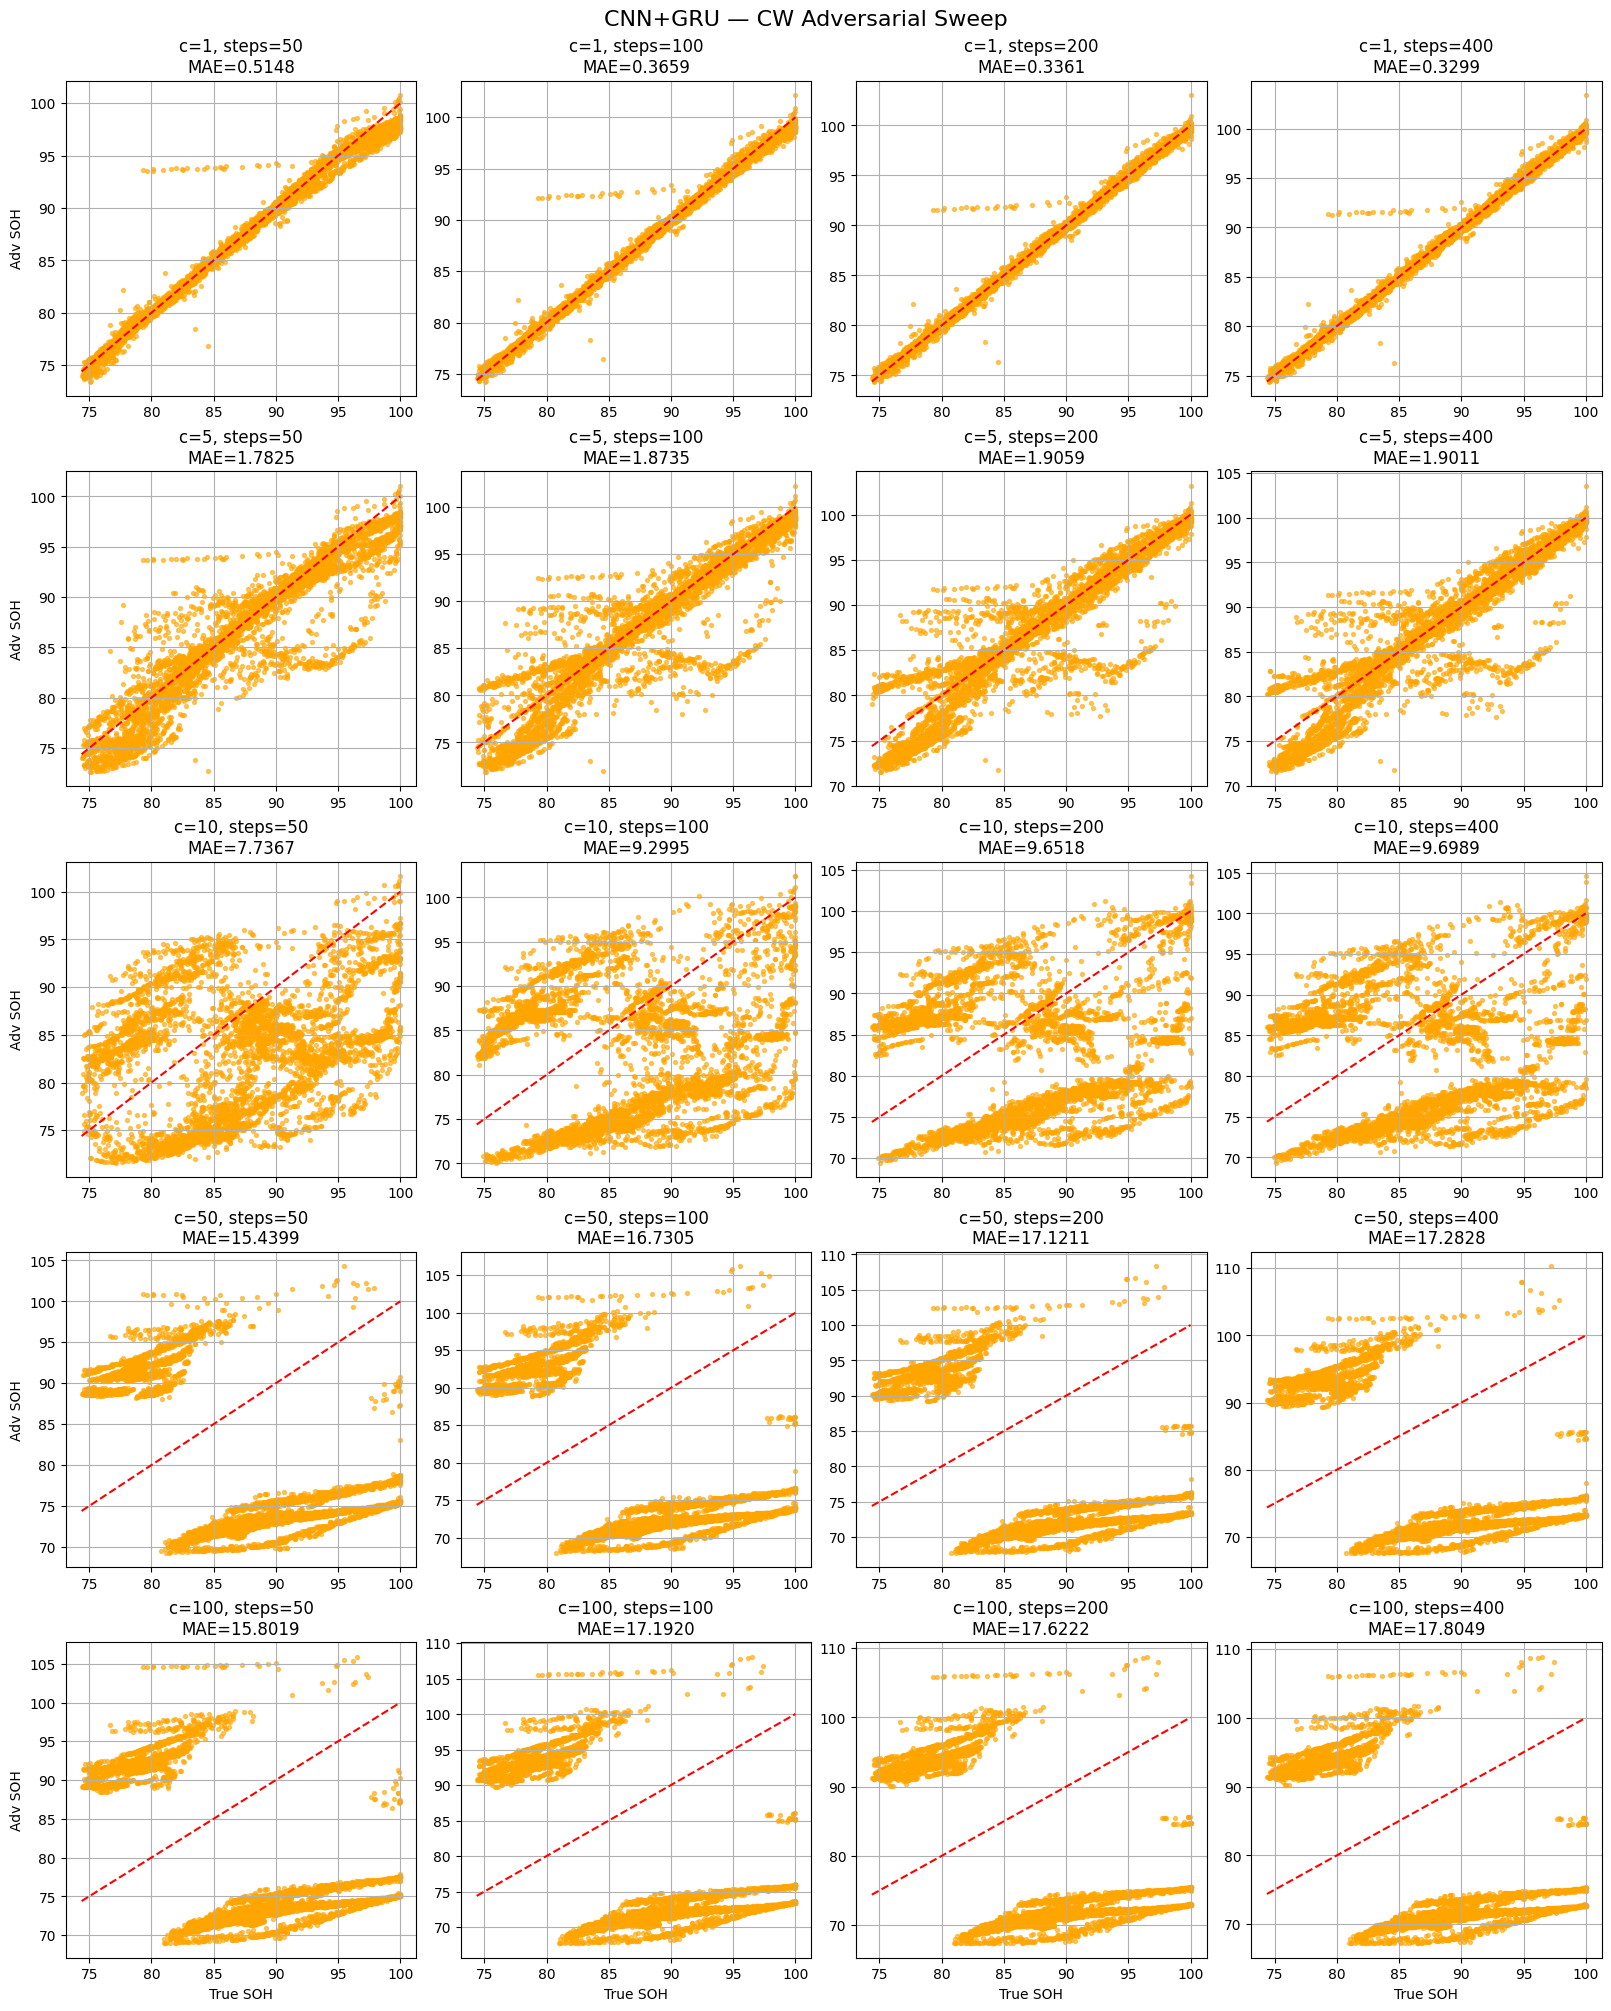


=== CW Attack Results : CNN+GRU ===
  c    Steps        MSE       MAE       ΔMSE      ΔMAE    Robustness
---  -------  ---------  --------  ---------  --------  ------------
  1       50    1.02322   0.51483    0.89248   0.26485      -0.05950
  1      100    0.60492   0.36592    0.47417   0.11594       0.53619
  1      200    0.52209   0.33606    0.39134   0.08608       0.65565
  1      400    0.49931   0.32985    0.36857   0.07987       0.68050
  5       50    7.80164   1.78253    7.67090   1.53255      -5.13069
  5      100    8.79049   1.87350    8.65974   1.62352      -5.49459
  5      200    9.22668   1.90589    9.09593   1.65591      -5.62414
  5      400    9.25257   1.90105    9.12183   1.65107      -5.60481
 10       50   75.31598   7.73666   75.18524   7.48668     -28.94906
 10      100  106.46367   9.29951  106.33293   9.04953     -35.20095
 10      200  115.20979   9.65175  115.07905   9.40177     -36.61001
 10      400  116.45004   9.69888  116.31930   9.44890     -36.798

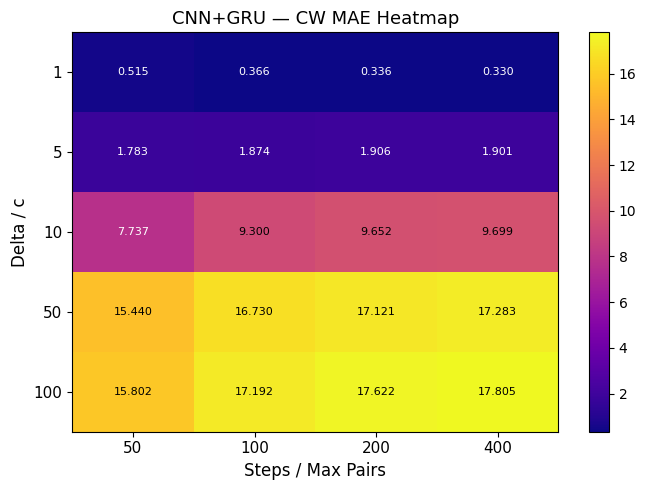

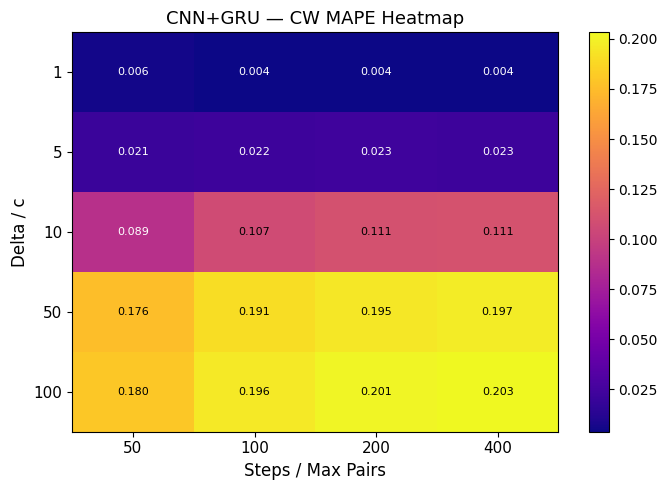

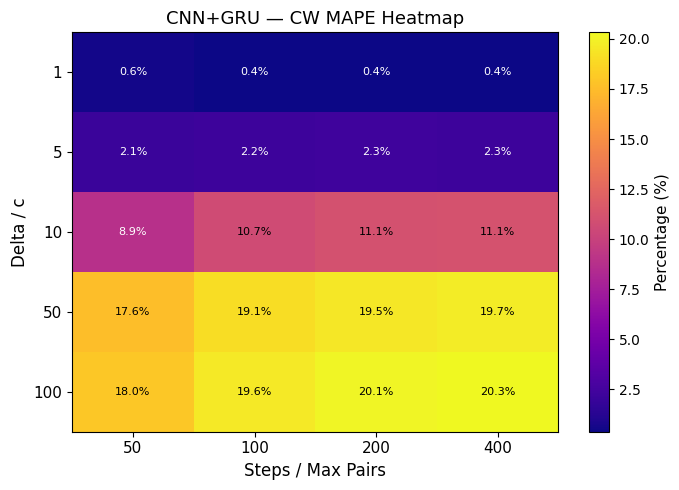

In [ ]:
print("--------")
print("CNN+GRU")
print("--------")

cnn_gru = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/attacks/CNN_GRU_NT.keras")

MAE_cnn_gru, MAPE_cnn_gru, table_cnn_gru = cw_attack_evaluation(
    model=cnn_gru,
    model_name="CNN+GRU",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    eps_list=eps_list,
    steps_list=steps_list,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)



---
RCN
---


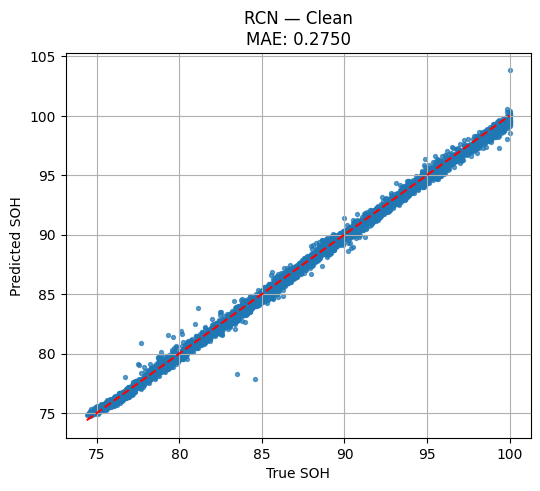

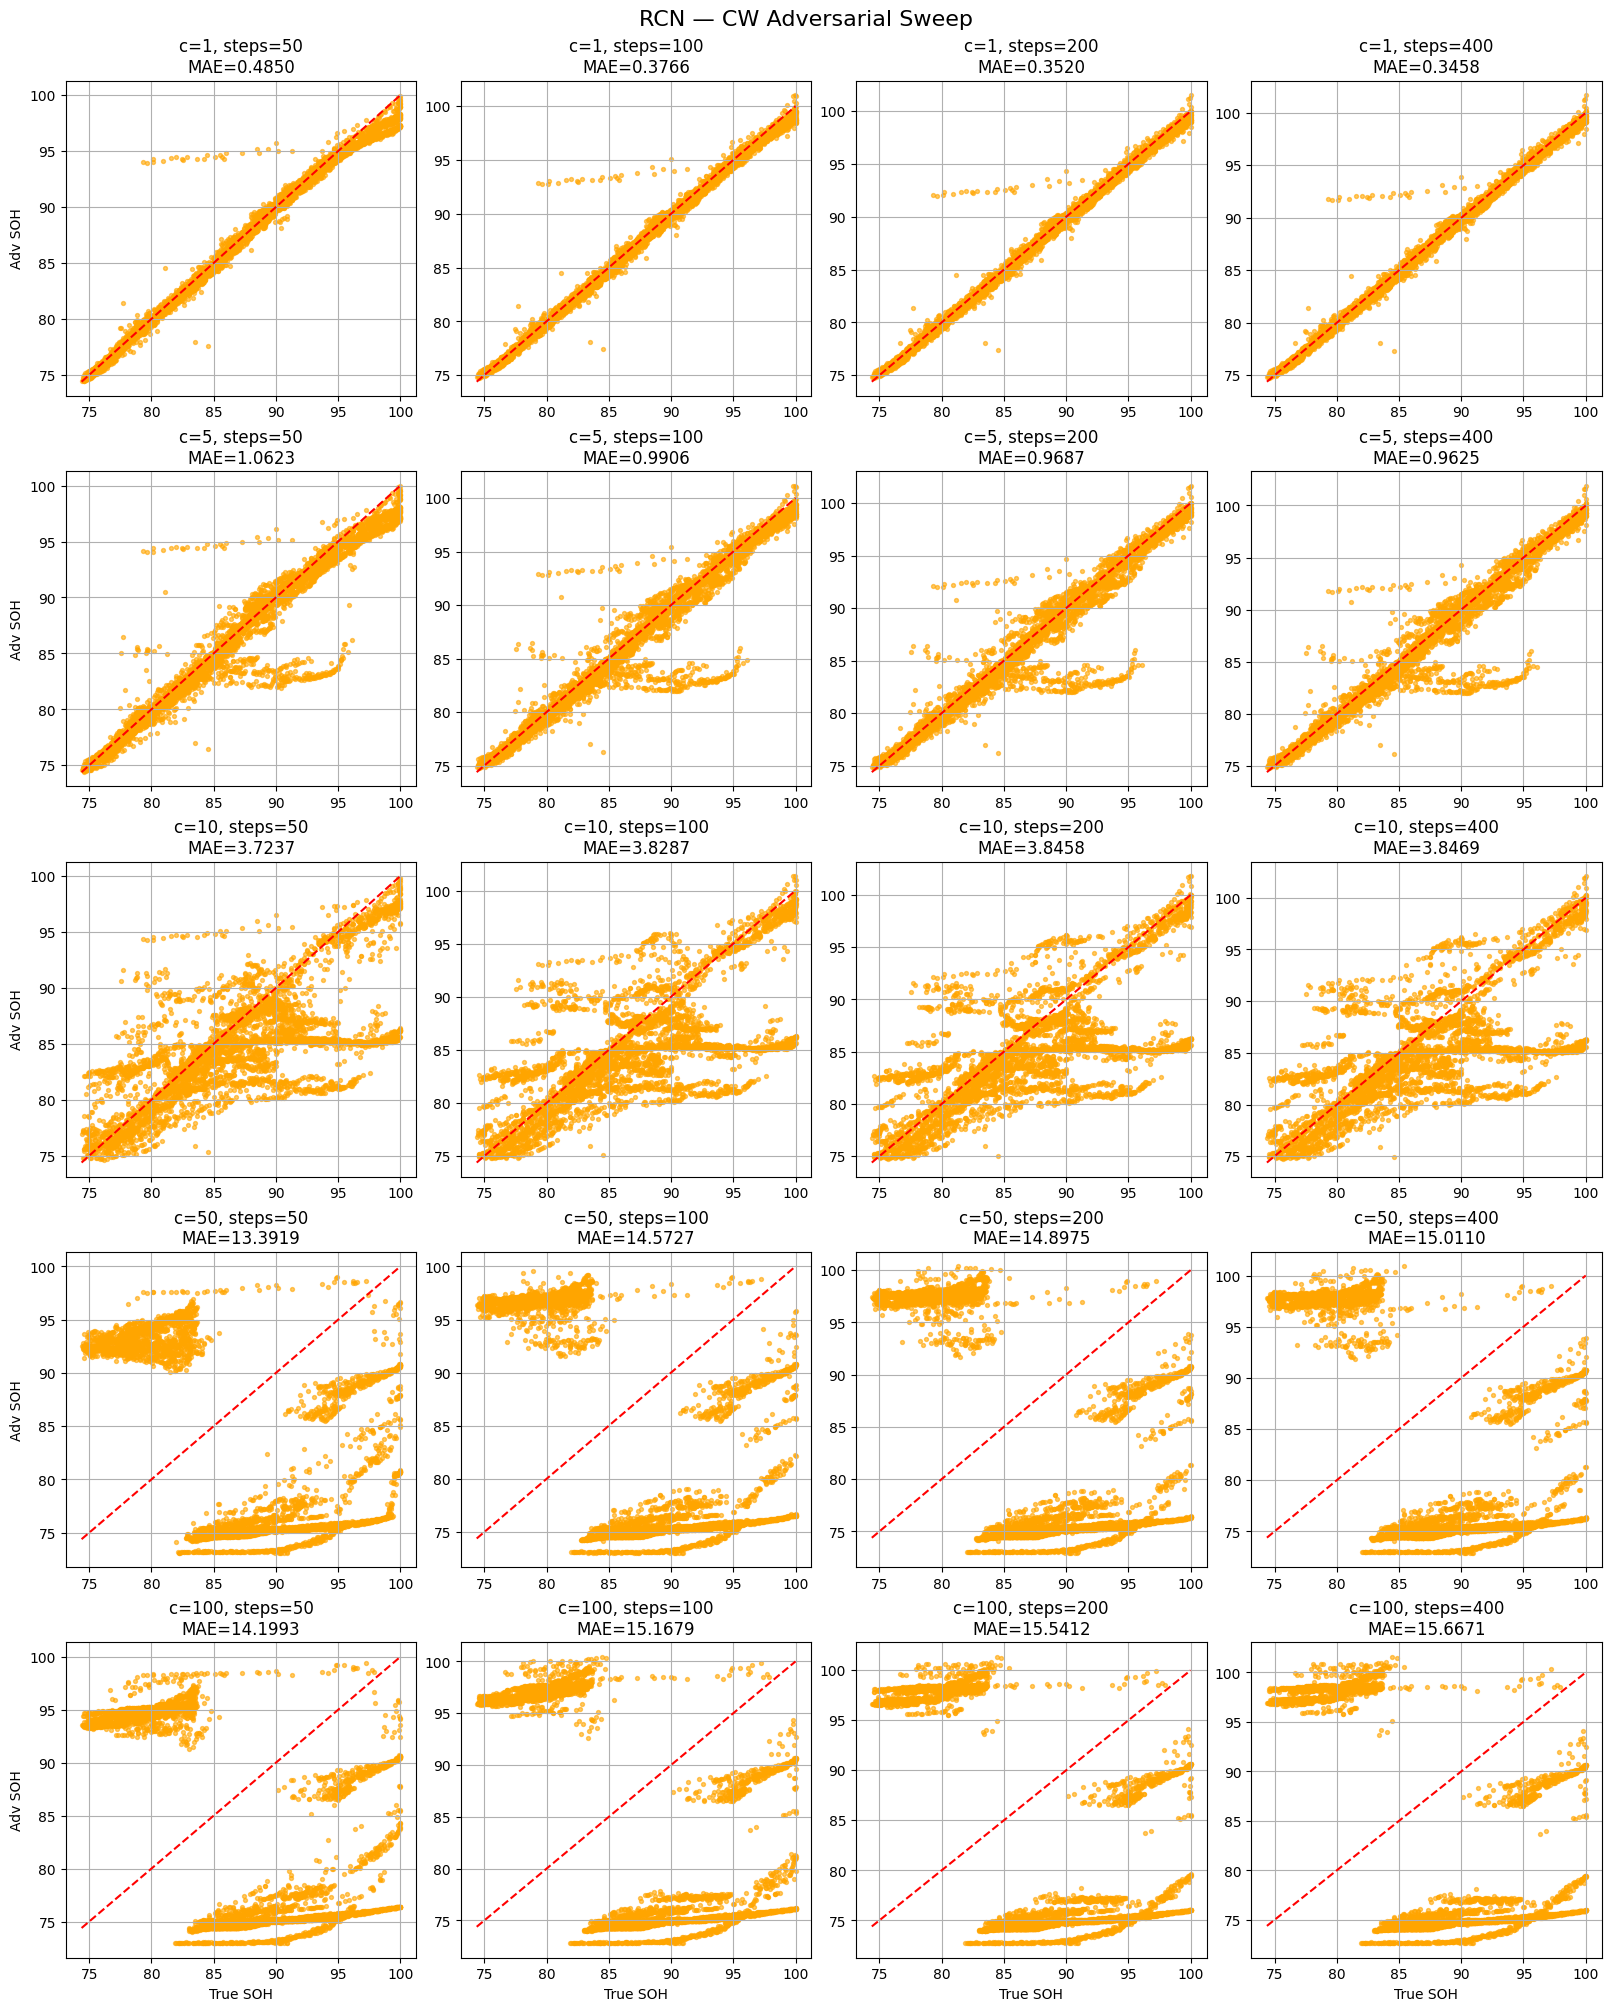


=== CW Attack Results : RCN ===
  c    Steps        MSE       MAE       ΔMSE      ΔMAE    Robustness
---  -------  ---------  --------  ---------  --------  ------------
  1       50    1.04115   0.48501    0.88920   0.21000       0.23638
  1      100    0.68663   0.37659    0.53468   0.10158       0.63061
  1      200    0.58631   0.35205    0.43435   0.07704       0.71986
  1      400    0.55240   0.34578    0.40045   0.07077       0.74266
  5       50    4.44811   1.06229    4.29616   0.78728      -1.86278
  5      100    4.18619   0.99055    4.03424   0.71555      -1.60193
  5      200    4.09704   0.96872    3.94509   0.69371      -1.52253
  5      400    4.06291   0.96255    3.91096   0.68754      -1.50010
 10       50   27.97164   3.72374   27.81968   3.44873     -11.54055
 10      100   29.17458   3.82871   29.02262   3.55370     -11.92225
 10      200   29.28789   3.84581   29.13594   3.57080     -11.98443
 10      400   29.27816   3.84686   29.12620   3.57185     -11.98825
 

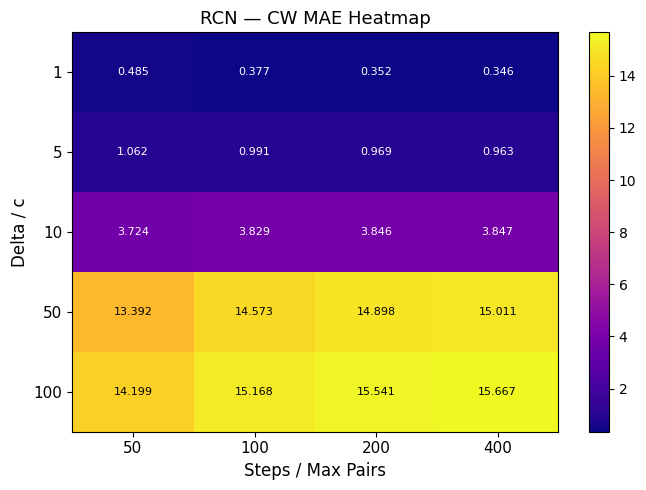

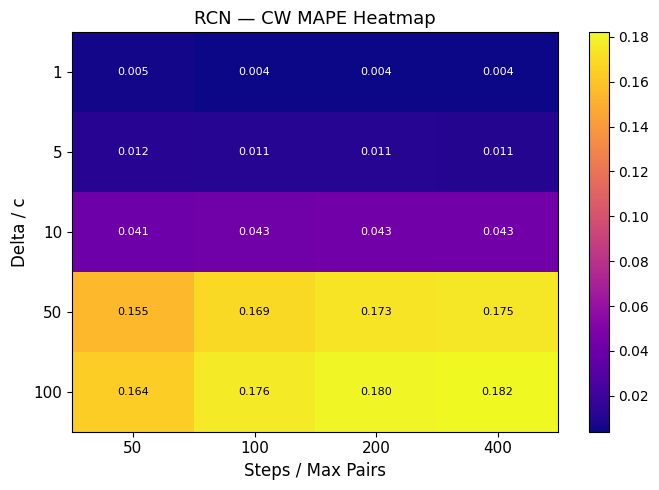

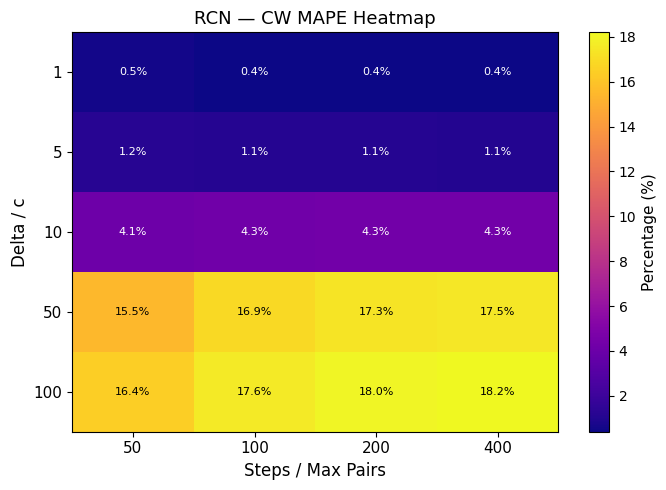

In [ ]:
print("---")
print("RCN")
print("---")

rcn = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/attacks/RCN_NT.keras")

MAE_rcn, MAPE_rcn, table_rcn = cw_attack_evaluation(
    model=rcn,
    model_name="RCN",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    eps_list=eps_list,
    steps_list=steps_list,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)



---
RCN AT
---


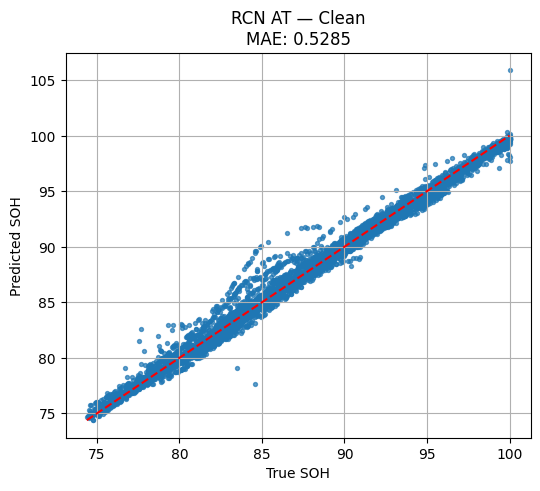

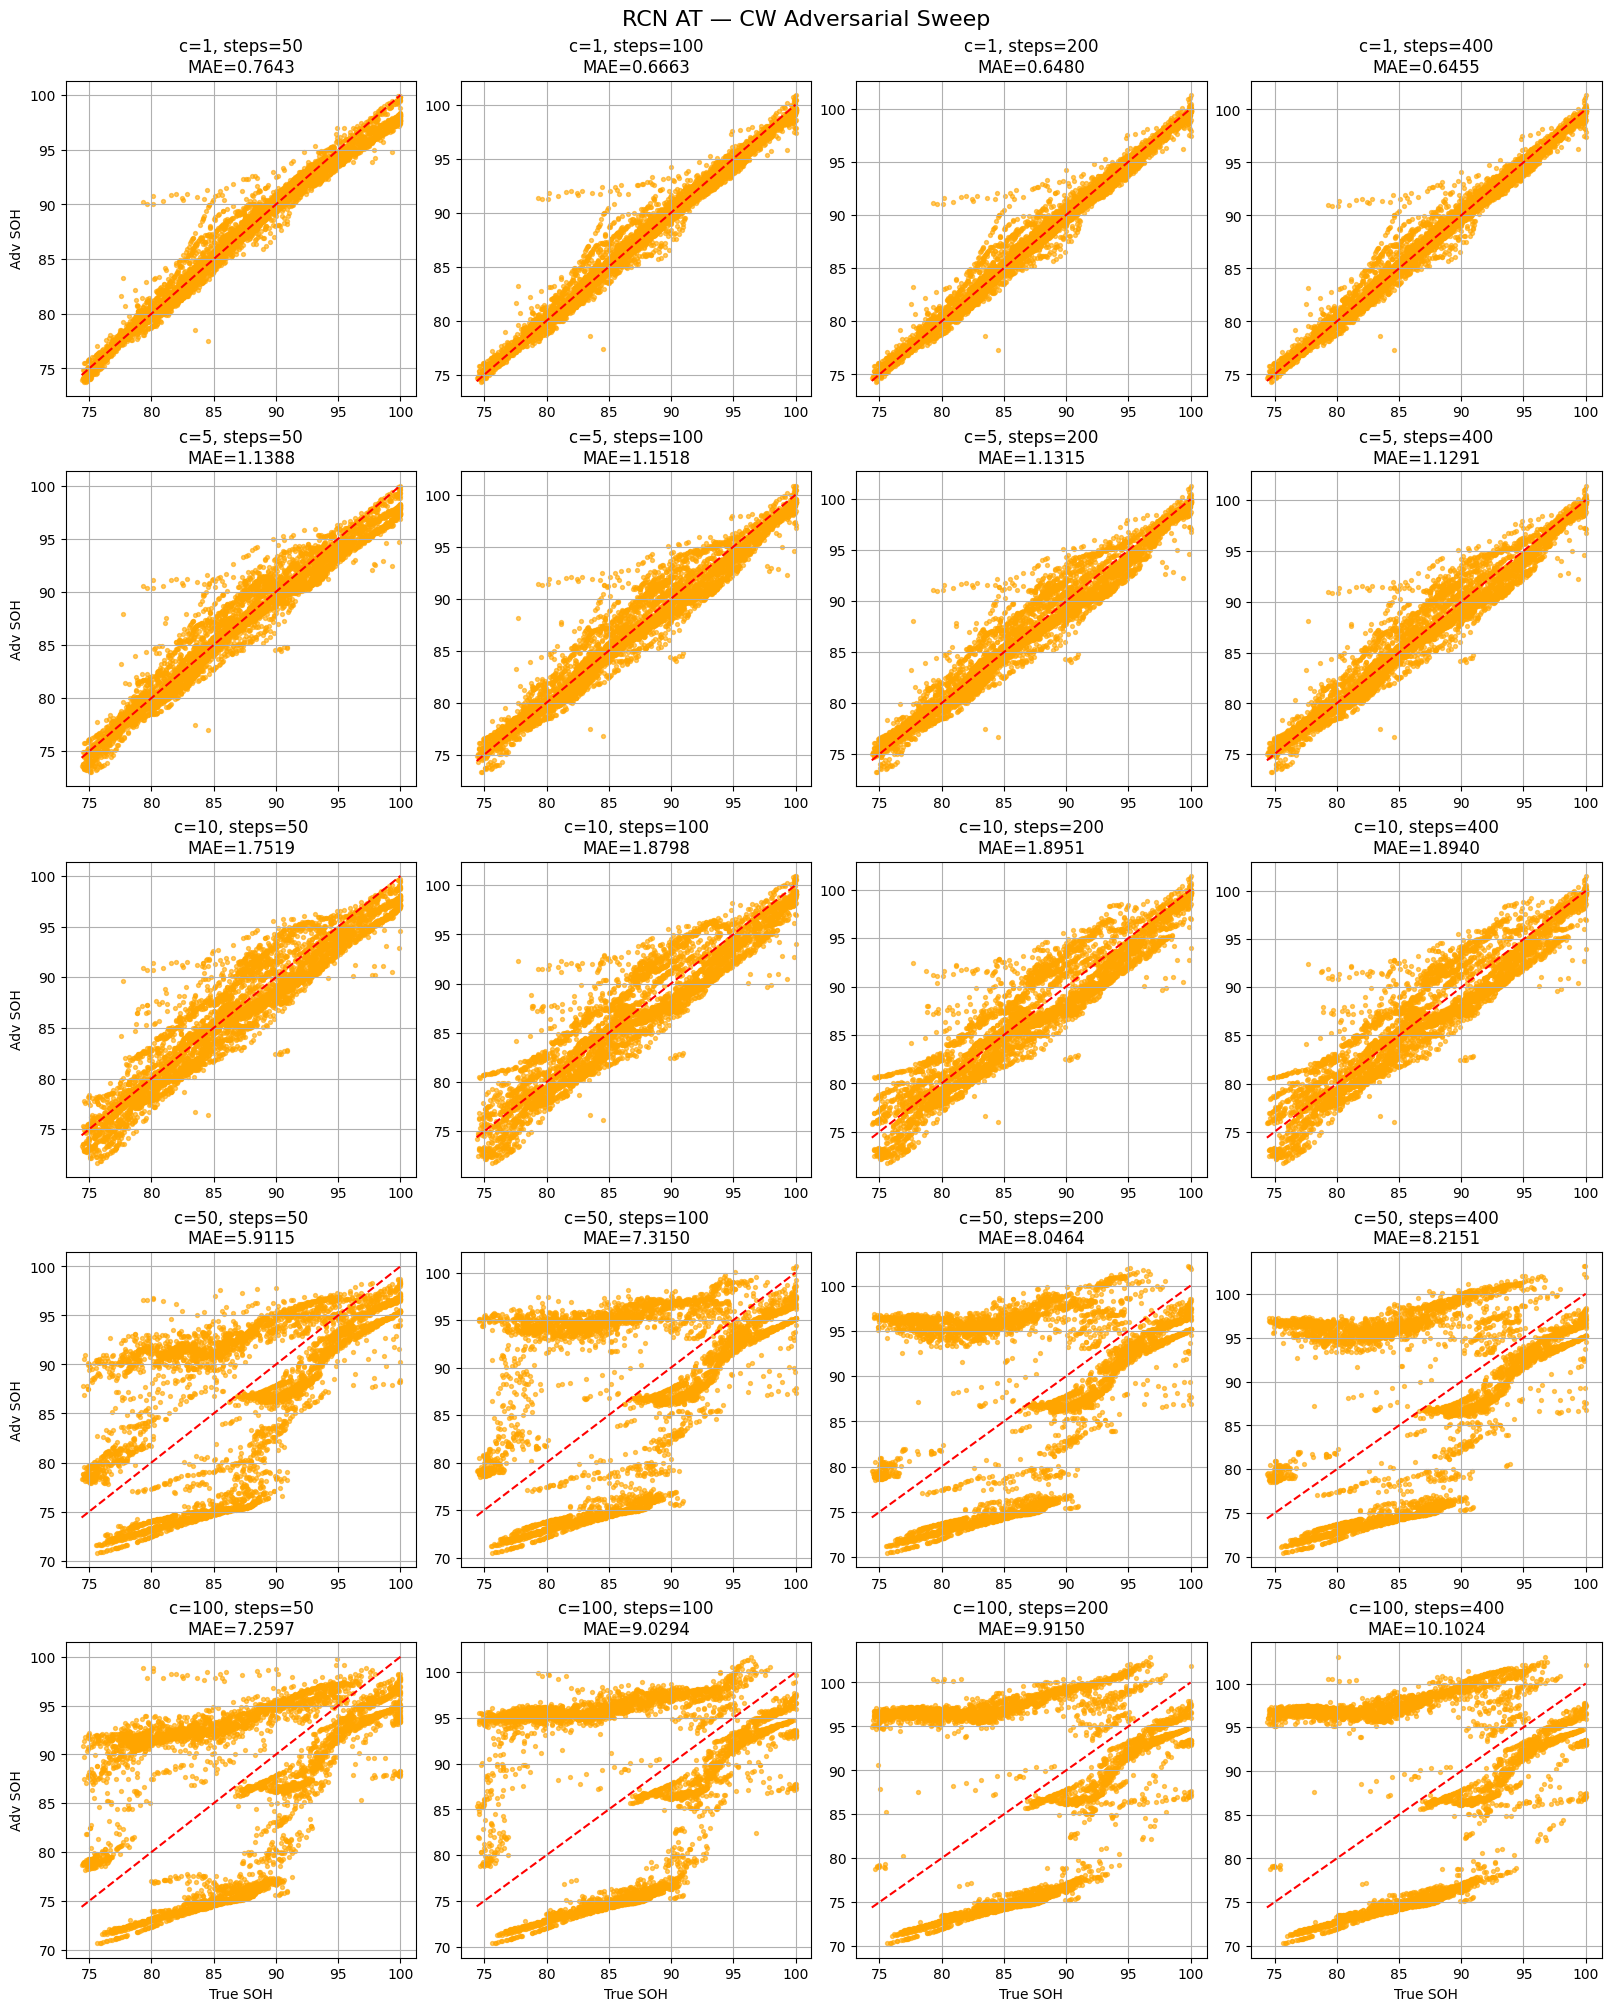


=== CW Attack Results : RCN AT ===
  c    Steps        MSE       MAE       ΔMSE     ΔMAE    Robustness
---  -------  ---------  --------  ---------  -------  ------------
  1       50    1.32449   0.76427    0.69903  0.23574       0.55397
  1      100    1.17846   0.66626    0.55301  0.13773       0.73941
  1      200    1.14296   0.64798    0.51751  0.11945       0.77399
  1      400    1.12586   0.64549    0.50041  0.11696       0.77870
  5       50    2.47133   1.13879    1.84588  0.61026      -0.15463
  5      100    2.58009   1.15180    1.95464  0.62327      -0.17925
  5      200    2.54936   1.13150    1.92391  0.60297      -0.14084
  5      400    2.53532   1.12912    1.90986  0.60059      -0.13635
 10       50    4.85033   1.75194    4.22488  1.22341      -1.31474
 10      100    5.54935   1.87980    4.92389  1.35127      -1.55666
 10      200    5.70438   1.89511    5.07893  1.36658      -1.58563
 10      400    5.74821   1.89398    5.12276  1.36545      -1.58349
 50       50

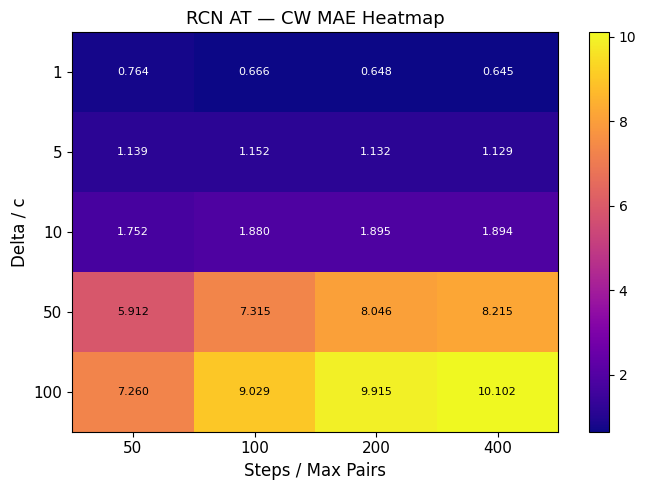

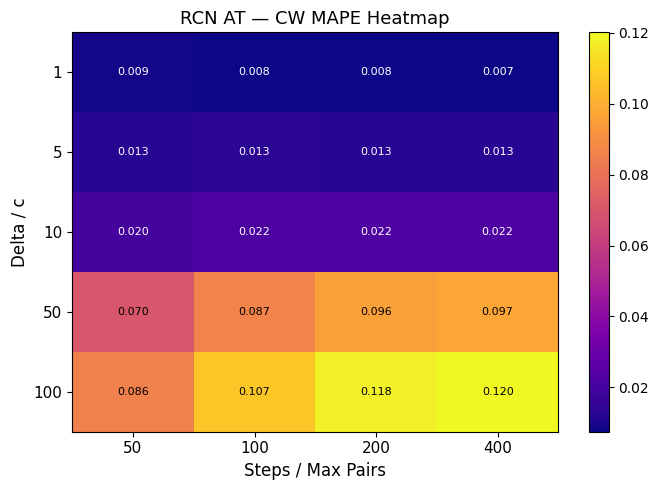

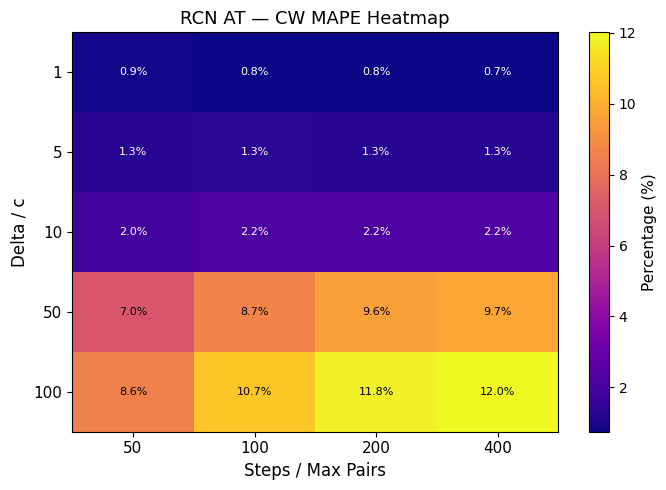

In [14]:
print("---")
print("RCN AT")
print("---")

rcn = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/RCN_CW_AT.keras")

MAE_rcn, MAPE_rcn, table_rcn = cw_attack_evaluation(
    model=rcn,
    model_name="RCN AT",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    eps_list=eps_list,
    steps_list=steps_list,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)



---
CNN
---


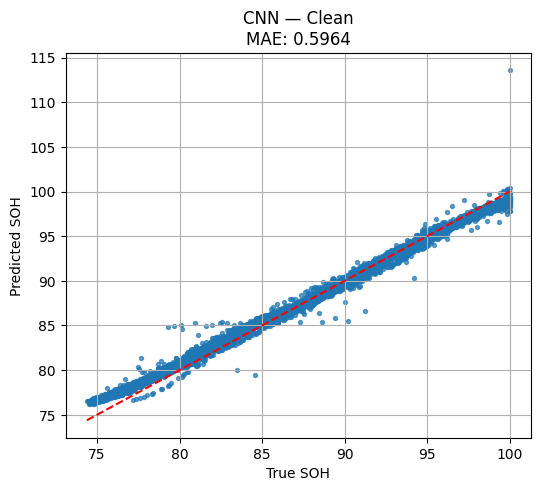

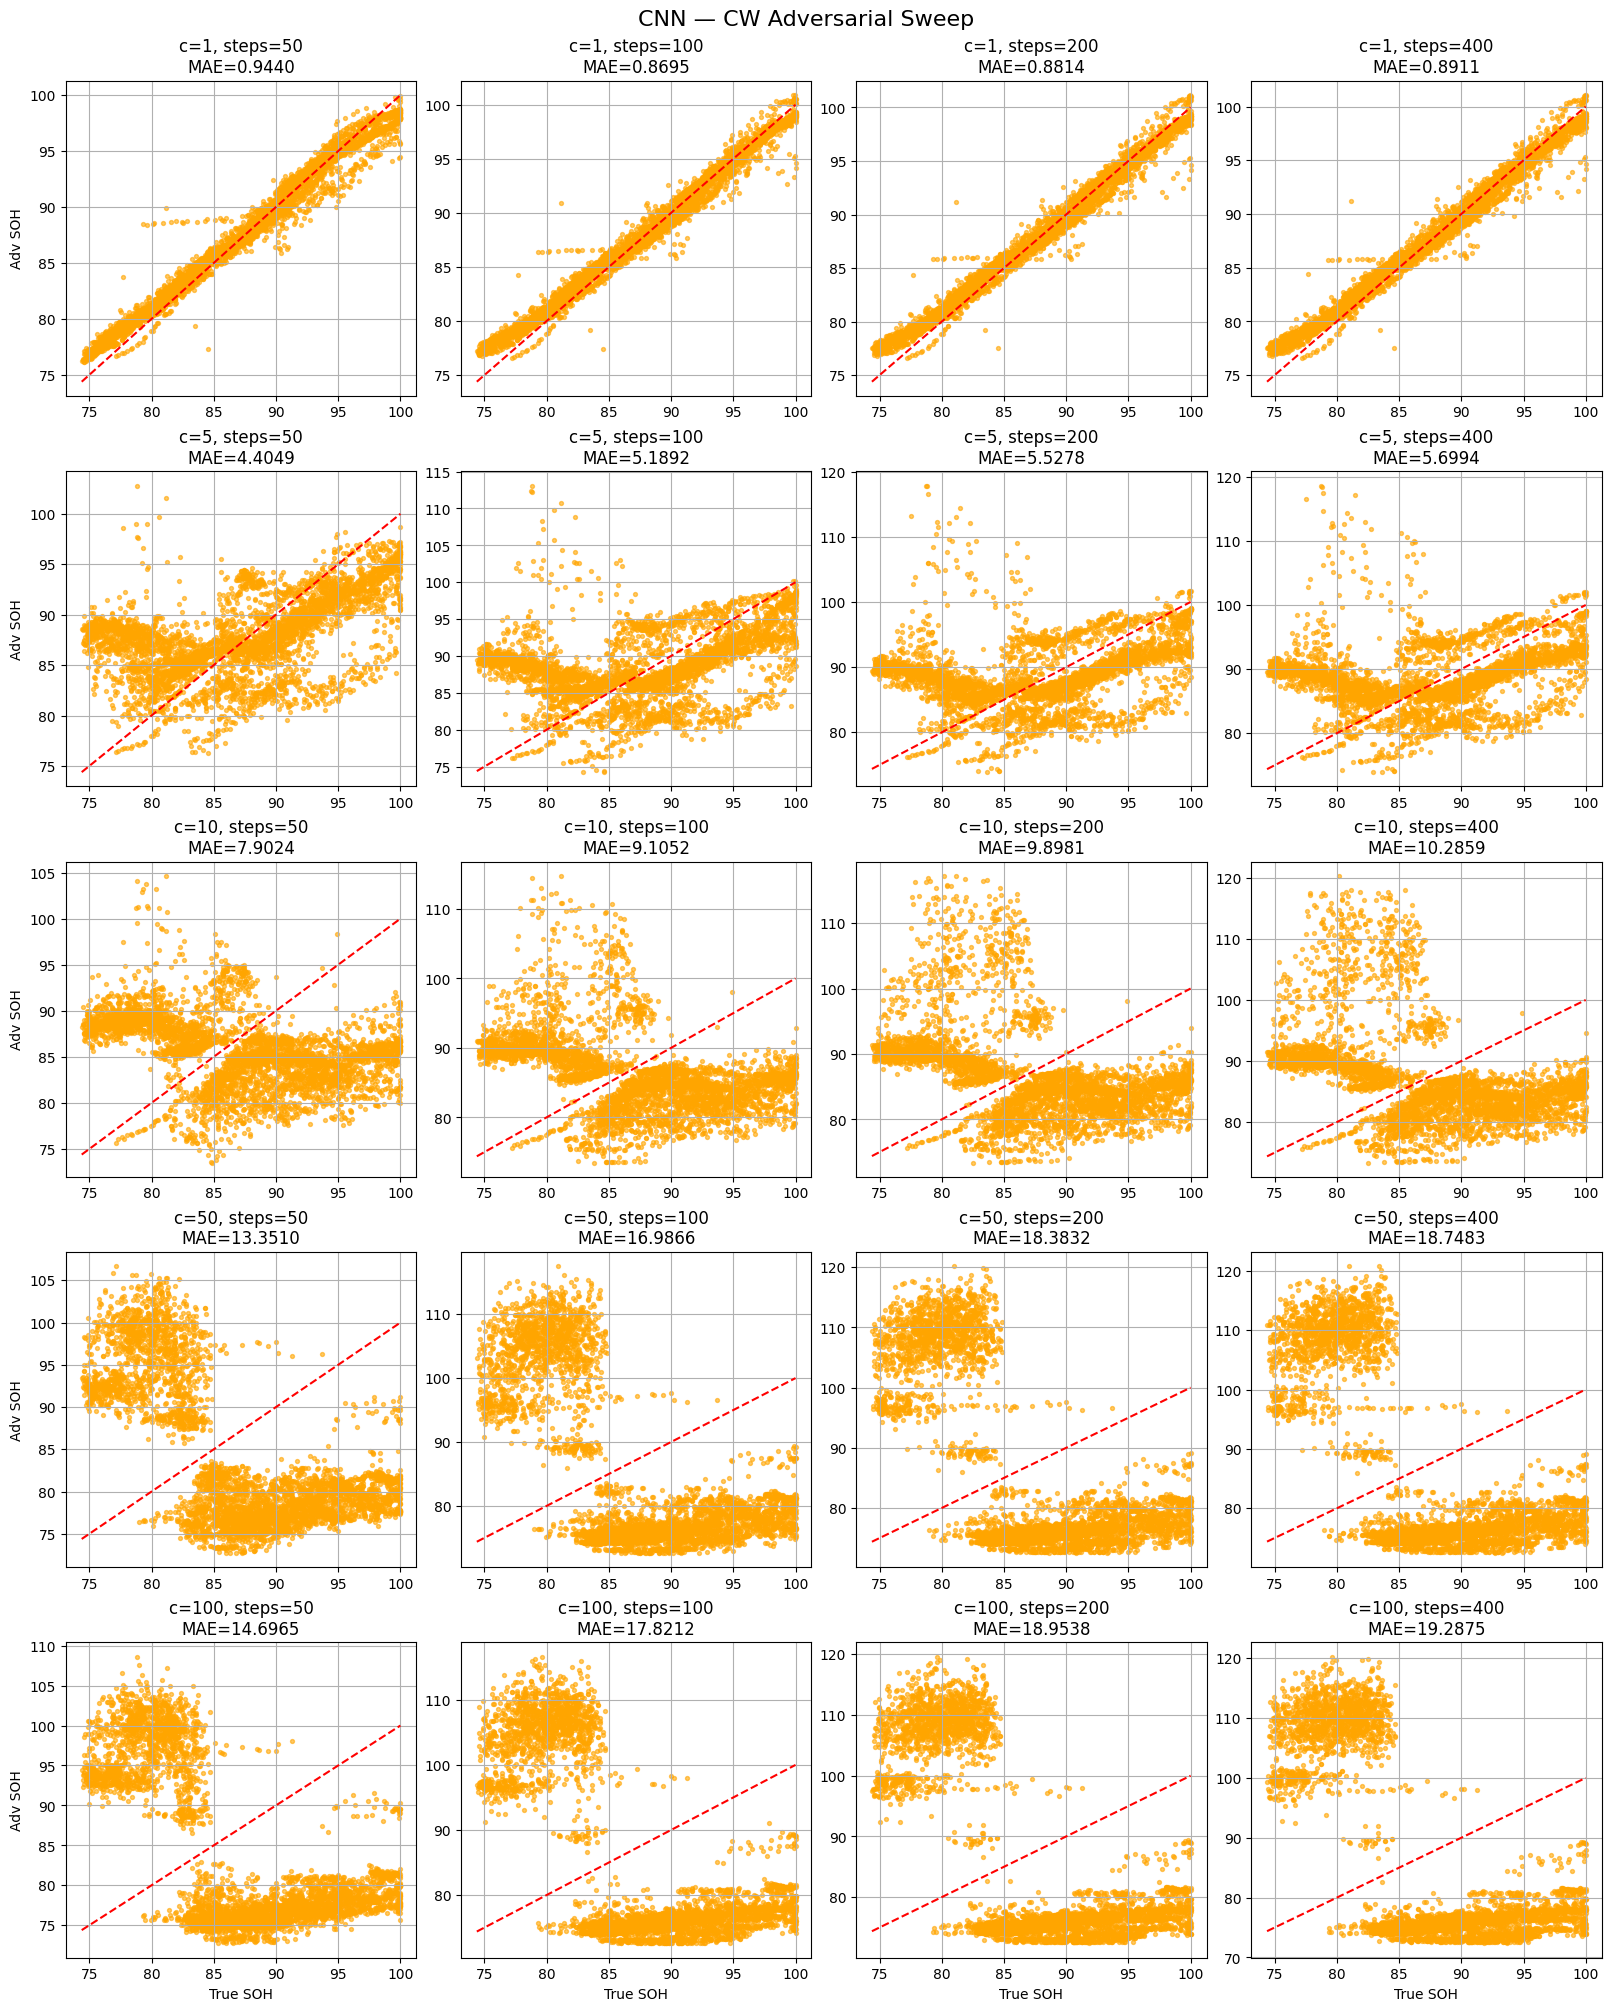


=== CW Attack Results : CNN ===
  c    Steps        MSE       MAE       ΔMSE      ΔMAE    Robustness
---  -------  ---------  --------  ---------  --------  ------------
  1       50    1.52323   0.94398    0.89258   0.34761       0.41713
  1      100    1.27624   0.86951    0.64560   0.27314       0.54199
  1      200    1.31579   0.88137    0.68514   0.28500       0.52212
  1      400    1.33875   0.89108    0.70810   0.29471       0.50583
  5       50   32.43214   4.40486   31.80149   3.80849      -5.38611
  5      100   45.55187   5.18916   44.92123   4.59279      -6.70124
  5      200   51.59496   5.52776   50.96432   4.93139      -7.26900
  5      400   54.40448   5.69936   53.77384   5.10299      -7.55675
 10       50   80.24885   7.90236   79.61821   7.30599     -11.25075
 10      100  108.18160   9.10517  107.55095   8.50879     -13.26763
 10      200  134.50282   9.89810  133.87218   9.30173     -14.59723
 10      400  149.33315  10.28586  148.70250   9.68949     -15.24743
 

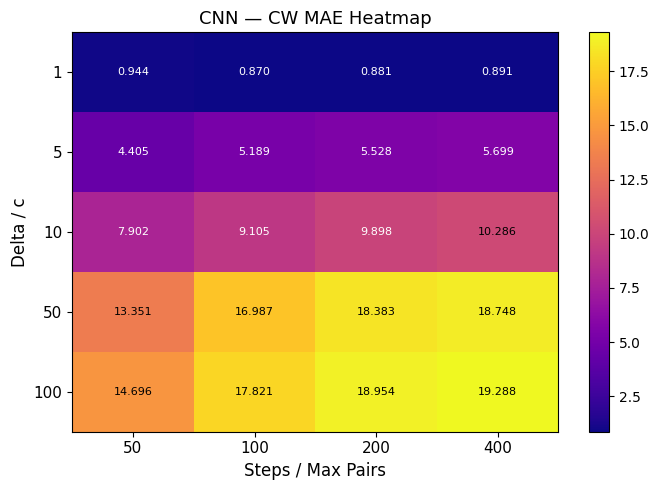

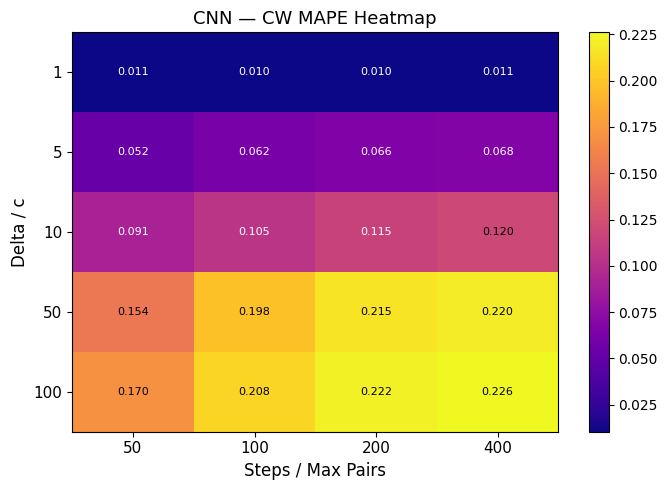

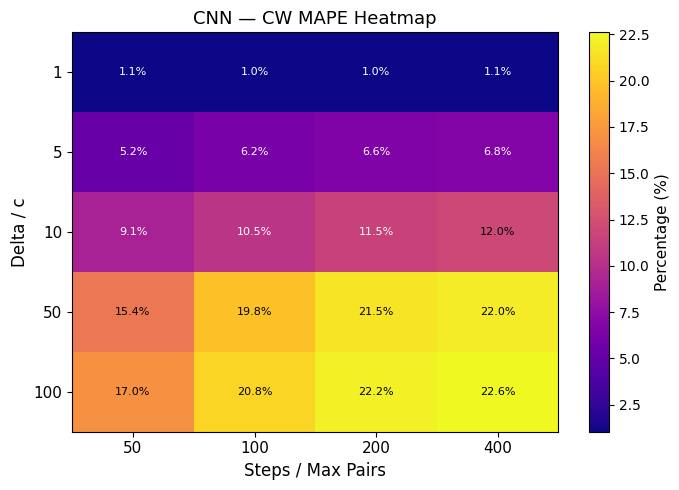

In [ ]:
print("---")
print("CNN")
print("---")

cnn = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/attacks/CNN_NT.keras")

MAE_cnn, MAPE_cnn, table_cnn = cw_attack_evaluation(
    model=cnn,
    model_name="CNN",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    eps_list=eps_list,
    steps_list=steps_list,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)

